[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/13_simple_search/notebooks/aplicaciones/04_coloreo_imagen.ipynb)


# Aplicación 04: Flood Fill y Segmentación de Imágenes

El flood fill es el algoritmo que usa cualquier programa de dibujo cuando rellenas una región. Internamente es BFS (o DFS) sobre un grafo de píxeles. Aquí lo implementaremos desde cero y lo usaremos para segmentar imágenes en sus regiones conectadas.

## El grafo de píxeles

Dada una imagen de $H \times W$ píxeles, construimos un grafo $G$ donde:
- $V = \{(r, c) : 0 \le r < H,\; 0 \le c < W\}$ — cada píxel es un vértice
- $(u, v) \in E$ si y solo si $u$ y $v$ son vecinos (4-conectados) **y** tienen el mismo color

El flood fill desde una semilla $(r_0, c_0)$ simplemente calcula la **componente conexa**
de $(r_0, c_0)$ en este grafo.

## Aplicaciones reales

- **Herramienta de relleno** (Paint, Photoshop): rellenar una región con un nuevo color
- **Segmentación de imágenes**: identificar regiones con color/intensidad similar
- **Detección de islas**: contar regiones conectadas en mapas binarios
- **Análisis médico**: segmentar tejidos en imágenes de resonancia magnética


In [2]:
# Solo en Colab — en entorno local estas librerías ya deben estar instaladas
import sys
if "google.colab" in sys.modules:
    !pip install -q numpy matplotlib


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Paleta de colores para las 4 regiones
PALETA_REGIONES = np.array([
    [0.22, 0.48, 0.85],   # azul
    [0.18, 0.72, 0.44],   # verde
    [0.95, 0.60, 0.15],   # naranja
    [0.80, 0.25, 0.30],   # rojo oscuro
])

NOMBRES_COLORES = ['Azul', 'Verde', 'Naranja', 'Rojo']

print("Dependencias cargadas.")


Dependencias cargadas.


---
## Motor de Búsqueda (auto-contenido)

Copiamos el motor BFS/DFS para que el notebook sea completamente independiente.


In [4]:
# ============================================================
# MOTOR DE BÚSQUEDA COMPLETO
# ============================================================

class Frontera:
    def push(self, nodo, padre=None): raise NotImplementedError
    def pop(self): raise NotImplementedError
    def contains(self, nodo): raise NotImplementedError
    def is_empty(self): raise NotImplementedError

class ColaDeFrontera(Frontera):
    def __init__(self):
        self.cola = deque()
        self.miembros = set()
    def push(self, nodo, padre=None):
        self.cola.append(nodo); self.miembros.add(nodo)
    def pop(self):
        nodo = self.cola.popleft(); self.miembros.discard(nodo); return nodo
    def contains(self, nodo): return nodo in self.miembros
    def is_empty(self): return len(self.cola) == 0

class PilaDeFrontera(Frontera):
    def __init__(self):
        self.pila = []
        self.miembros = set()
    def push(self, nodo, padre=None):
        self.pila.append(nodo); self.miembros.add(nodo)
    def pop(self):
        nodo = self.pila.pop(); self.miembros.discard(nodo); return nodo
    def contains(self, nodo): return nodo in self.miembros
    def is_empty(self): return len(self.pila) == 0

def busqueda_generica_flood(problema, frontera):
    """
    Variante para flood fill: no tiene meta, explora toda la componente.
    Devuelve la lista de todos los nodos visitados en orden.
    """
    inicio = problema.inicio
    frontera.push(inicio)
    explorado = set()
    explorado.add(inicio)
    orden_visita = []

    while not frontera.is_empty():
        nodo = frontera.pop()
        orden_visita.append(nodo)
        for vecino in problema.vecinos(nodo):
            if vecino not in explorado and not frontera.contains(vecino):
                explorado.add(vecino)
                frontera.push(vecino, padre=nodo)

    return orden_visita


class Problema:
    inicio = None
    def es_meta(self, nodo): raise NotImplementedError
    def vecinos(self, nodo): raise NotImplementedError


print("Motor de búsqueda listo.")


Motor de búsqueda listo.


---
## Sección 1: La Grilla de Píxeles como Grafo

Generaremos una grilla de $20 \times 20$ píxeles con 4 regiones de colores usando
una aproximación de diagramas de Voronoi: cada píxel se asigna al centro más cercano.

Con 4 centros ubicados en las esquinas, las regiones formarán cuatro cuadrantes
aproximados. Añadimos un poco de ruido para hacer las fronteras irregulares
— más parecidas a una imagen real.

### Definición del grafo de píxeles

Dos píxeles $(r_1, c_1)$ y $(r_2, c_2)$ son **vecinos** en el grafo si:
1. Son adyacentes en la cuadrícula (4-conectados): $|r_1 - r_2| + |c_1 - c_2| = 1$
2. Tienen el **mismo color**: $\text{color}(r_1, c_1) = \text{color}(r_2, c_2)$

Este criterio define las **regiones conectadas** de la imagen.


In [5]:
def generar_grilla_colores(filas=20, cols=20, seed=42):
    """
    Genera una grilla con 4 regiones de colores usando Voronoi aproximado.
    Cada celda tiene un color ID en {0, 1, 2, 3}.
    Añade ruido para crear fronteras irregulares.
    """
    np.random.seed(seed)
    centros = [(4, 4), (4, 15), (15, 4), (15, 15)]
    grid = np.zeros((filas, cols), dtype=int)

    for r in range(filas):
        for c in range(cols):
            dists = [((r - cr)**2 + (c - cc)**2) for cr, cc in centros]
            # Agregar ruido: desplazar ligeramente las distancias
            ruido = np.random.uniform(-3, 3, size=4)
            dists_ruidosas = [d + rn for d, rn in zip(dists, ruido)]
            grid[r, c] = int(np.argmin(dists_ruidosas))

    return grid


grid_colores = generar_grilla_colores(20, 20, seed=42)

print("Grilla generada:")
print(grid_colores)
print()
for i in range(4):
    count = np.sum(grid_colores == i)
    print(f"  Color {i} ({NOMBRES_COLORES[i]}): {count} píxeles")


Grilla generada:
[[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
 [2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3]
 [2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3]
 [2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3]
 [2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3]
 [2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3]
 [2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3]
 [2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3]
 [2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3]
 [2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3]
 [2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3]]

  Color 0 (Azul): 100 píxeles
  Color 1 (Verde): 100 píxeles
  Color 2 (Naranja): 100 píxeles
  Color 3 (Rojo): 100 píxel

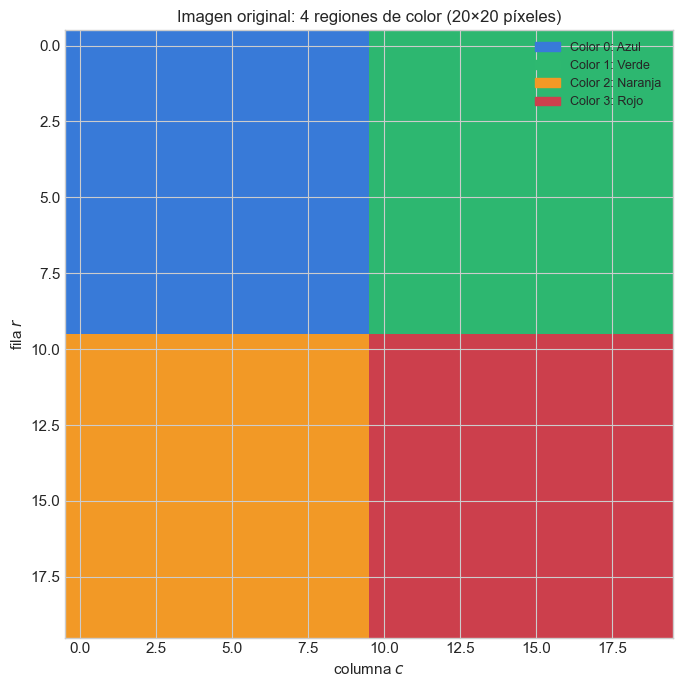

Cada píxel tiene un ID de color en {0, 1, 2, 3}.
Dos píxeles son vecinos (en el grafo) si son adyacentes Y tienen el mismo color.


In [6]:
def grilla_a_imagen(grid, paleta=PALETA_REGIONES):
    """Convierte una grilla de IDs de color a una imagen RGB usando la paleta."""
    filas, cols = grid.shape
    img = np.zeros((filas, cols, 3))
    for i in range(len(paleta)):
        mascara = (grid == i)
        img[mascara] = paleta[i]
    return img


img_original = grilla_a_imagen(grid_colores)

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img_original, interpolation='nearest', aspect='equal')
ax.set_title('Imagen original: 4 regiones de color (20×20 píxeles)', fontsize=12)
ax.set_xlabel('columna $c$')
ax.set_ylabel('fila $r$')

# Leyenda de colores
parches = [mpatches.Patch(color=PALETA_REGIONES[i], label=f'Color {i}: {NOMBRES_COLORES[i]}')
           for i in range(4)]
ax.legend(handles=parches, loc='upper right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

print("Cada píxel tiene un ID de color en {0, 1, 2, 3}.")
print("Dos píxeles son vecinos (en el grafo) si son adyacentes Y tienen el mismo color.")


---
## Sección 2: Flood Fill con BFS

El flood fill busca **todos los píxeles de la misma región** alcanzables desde una semilla.
No hay una meta explícita — exploramos toda la componente conexa.

```
flood_fill(semilla s, color c):
    frontera = {s}
    visitados = {s}
    mientras frontera no vacía:
        p ← sacar de la frontera
        para cada vecino q de p:
            si color(q) = c y q no visitado:
                agregar q a frontera y visitados
    retornar visitados
```

Con BFS, los píxeles se visitan en orden de **distancia Manhattan** desde la semilla.
Visualmente, la región se "llena" de adentro hacia afuera, como círculos concéntricos.


In [7]:
class ProblemaPixeles(Problema):
    """
    Flood fill: encontrar todos los píxeles conectados del mismo color desde una semilla.
    Los vecinos son los 4 píxeles adyacentes (arriba, abajo, izquierda, derecha)
    que tengan el MISMO color que la semilla.
    """
    def __init__(self, grid, semilla):
        self.grid = grid
        self.inicio = semilla
        self.color_semilla = int(grid[semilla[0], semilla[1]])
        self.filas, self.cols = grid.shape

    def es_meta(self, nodo):
        return False  # sin meta — exploramos toda la componente

    def vecinos(self, nodo):
        r, c = nodo
        result = []
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = r + dr, c + dc
            if (0 <= nr < self.filas and
                    0 <= nc < self.cols and
                    int(self.grid[nr, nc]) == self.color_semilla):
                result.append((nr, nc))
        return result


# Semilla en el centro-izquierda
semilla = (10, 3)
color_semilla = int(grid_colores[semilla[0], semilla[1]])
print(f"Semilla: {semilla}  |  Color: {color_semilla} ({NOMBRES_COLORES[color_semilla]})")

problema_px = ProblemaPixeles(grid_colores, semilla)

# BFS flood fill
orden_bfs = busqueda_generica_flood(problema_px, ColaDeFrontera())
region_bfs = set(orden_bfs)

print(f"Flood fill BFS: {len(region_bfs)} píxeles en la región")


Semilla: (10, 3)  |  Color: 2 (Naranja)
Flood fill BFS: 100 píxeles en la región


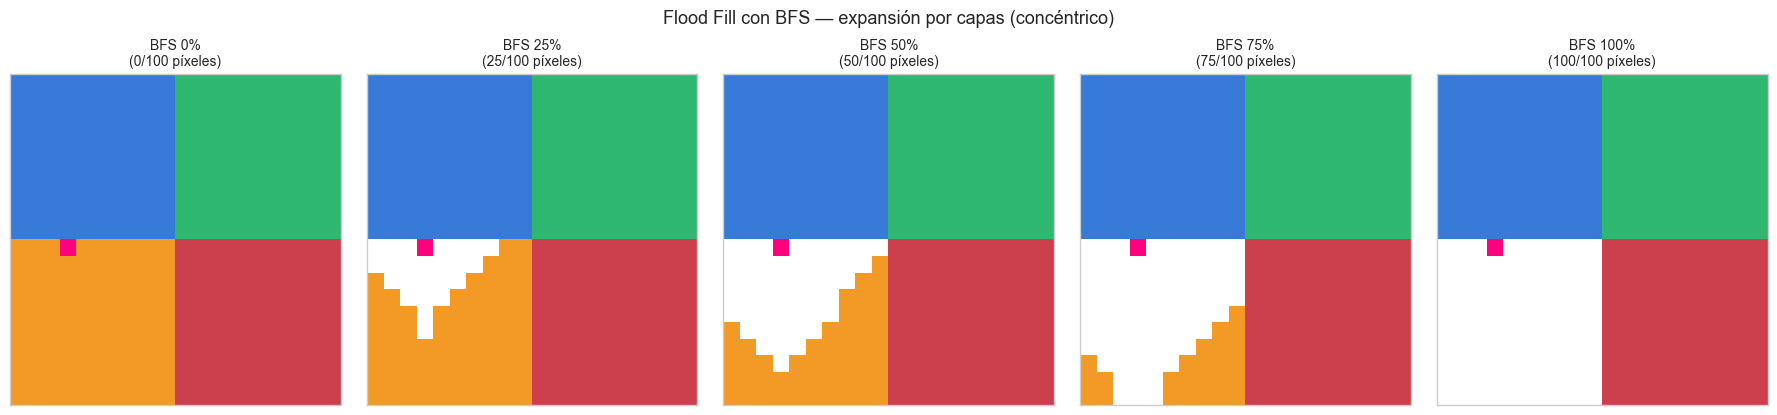

BFS llena la región capa por capa, como ondas en el agua.
Los píxeles más cercanos a la semilla se visitan primero.


In [8]:
def visualizar_flood(grid, orden_visita, semilla, titulo, ax, progreso=1.0):
    """
    Visualiza la imagen con la región flood-fill completada hasta 'progreso' (0.0 a 1.0).
    """
    img = grilla_a_imagen(grid).copy()
    n_mostrar = int(len(orden_visita) * progreso)
    pixeles_visitados = set(orden_visita[:n_mostrar])

    # Resaltar con blanco brillante los píxeles visitados
    for (r, c) in pixeles_visitados:
        img[r, c] = [1.0, 1.0, 1.0]  # blanco = "relleno"

    # Marcar la semilla
    img[semilla[0], semilla[1]] = [1.0, 0.0, 0.5]  # rosa fuerte = semilla

    ax.imshow(img, interpolation='nearest', aspect='equal')
    ax.set_title(f"{titulo}\n({n_mostrar}/{len(orden_visita)} píxeles)", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])


# Mostrar 5 instantáneas del proceso BFS
progresos = [0.0, 0.25, 0.5, 0.75, 1.0]
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, prog in zip(axes, progresos):
    visualizar_flood(grid_colores, orden_bfs, semilla,
                     f"BFS {int(prog*100)}%", ax, progreso=prog)

plt.suptitle('Flood Fill con BFS — expansión por capas (concéntrico)', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

print("BFS llena la región capa por capa, como ondas en el agua.")
print("Los píxeles más cercanos a la semilla se visitan primero.")


---
## Sección 3: Flood Fill con DFS

Con DFS, el orden de exploración es completamente diferente. DFS se sumerge en
una dirección hasta llegar al borde de la región, luego retrocede.

El **conjunto final** de píxeles visitados es idéntico al de BFS — ambos encuentran
exactamente la misma componente conexa. La diferencia es el **orden** en que se visitan.

BFS: orden concéntrico → buen para calcular distancias, "relleno visual" uniforme
DFS: orden profundo → más eficiente en memoria, pero el "relleno visual" es errático


In [9]:
# DFS flood fill (misma semilla)
orden_dfs = busqueda_generica_flood(problema_px, PilaDeFrontera())
region_dfs = set(orden_dfs)

print(f"Flood fill DFS: {len(region_dfs)} píxeles en la región")
print(f"Flood fill BFS: {len(region_bfs)} píxeles en la región")
print(f"Misma región: {region_bfs == region_dfs}")
print()
print("✓ BFS y DFS encuentran exactamente la misma componente conexa.")
print("  Solo difieren en el ORDEN de visita.")


Flood fill DFS: 100 píxeles en la región
Flood fill BFS: 100 píxeles en la región
Misma región: True

✓ BFS y DFS encuentran exactamente la misma componente conexa.
  Solo difieren en el ORDEN de visita.


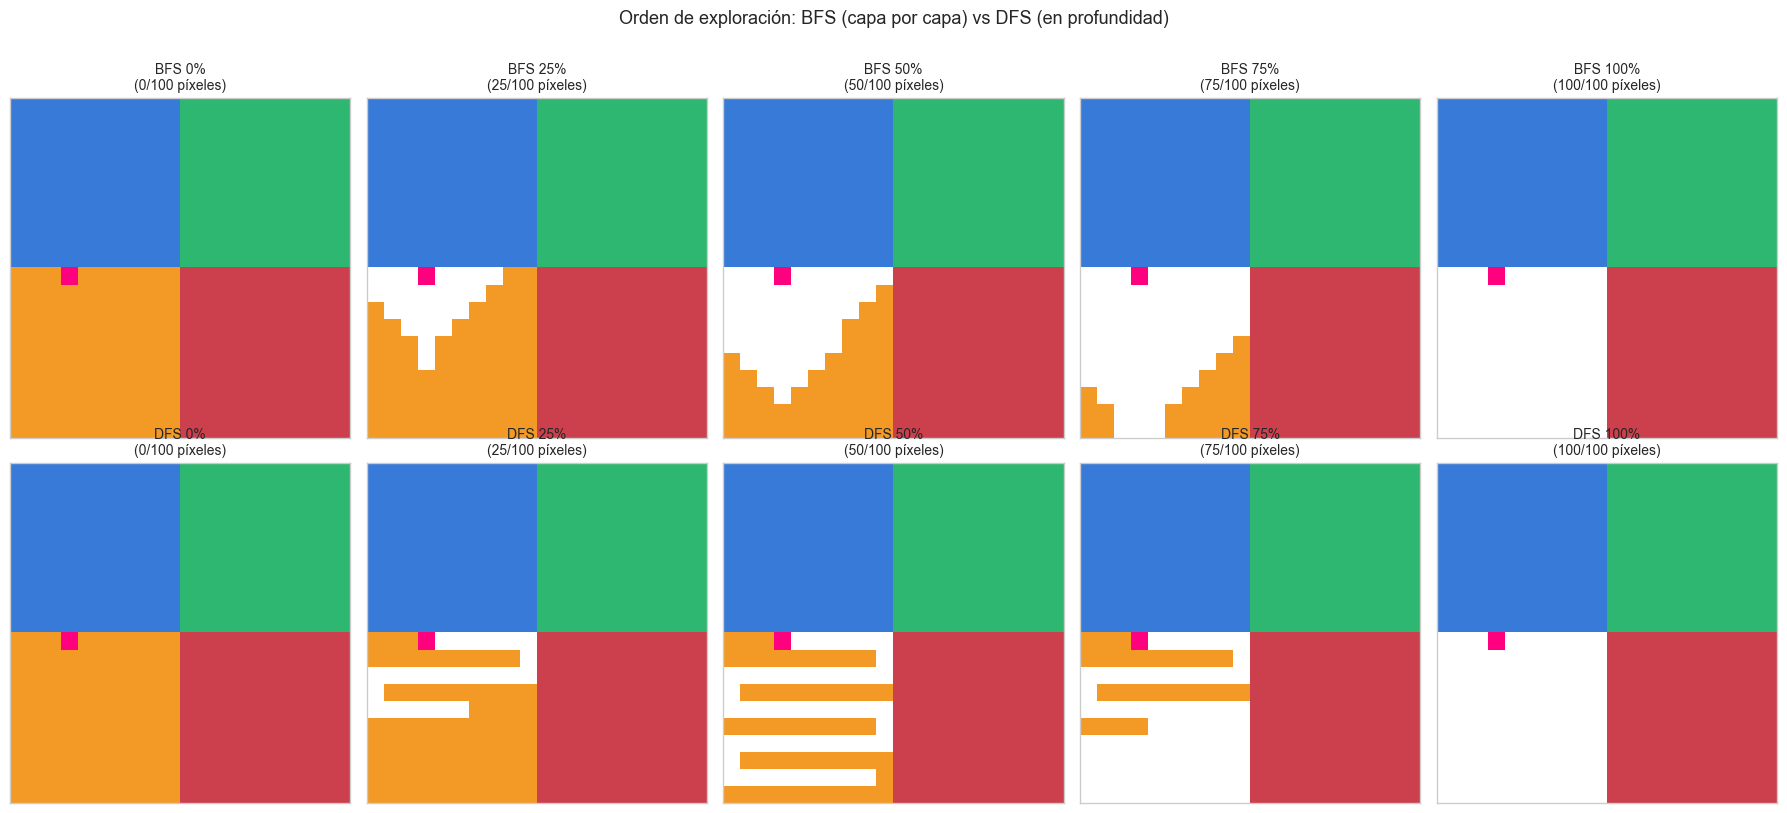

Observación clave:
  BFS al 25%: cubre uniformemente el centro de la región
  DFS al 25%: ya alcanzó un borde lejano pero dejó zonas sin visitar


In [10]:
# Comparar el orden de expansión visualmente
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i, prog in enumerate(progresos):
    visualizar_flood(grid_colores, orden_bfs, semilla,
                     f"BFS {int(prog*100)}%", axes[0, i], progreso=prog)
    visualizar_flood(grid_colores, orden_dfs, semilla,
                     f"DFS {int(prog*100)}%", axes[1, i], progreso=prog)

plt.suptitle('Orden de exploración: BFS (capa por capa) vs DFS (en profundidad)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Observación clave:")
print("  BFS al 25%: cubre uniformemente el centro de la región")
print("  DFS al 25%: ya alcanzó un borde lejano pero dejó zonas sin visitar")


---
## Sección 4: Encontrar Todas las Componentes Conexas

Para segmentar la imagen completa, necesitamos encontrar **todas** las regiones conectadas
de **todos** los colores. El algoritmo es:

```
para cada píxel (r, c) no etiquetado:
    etiqueta_siguiente ← nueva etiqueta
    flood_fill desde (r, c)
    asignar etiqueta_siguiente a todos los píxeles visitados
```

La complejidad total es $O(H \times W)$ — cada píxel se procesa exactamente una vez
(al hacer flood fill desde él, o al ser visitado durante el flood fill de otro).

Esto es equivalente a encontrar todos los componentes conexos de un grafo en $O(V + E)$.


In [11]:
def encontrar_componentes(grid):
    """
    Encuentra todas las componentes conexas de la imagen.
    Retorna:
        etiquetas: array de misma forma que grid, con ID de componente en cada píxel
        componentes: lista de (color, set_de_pixeles) para cada componente
    """
    filas, cols = grid.shape
    etiquetas = np.full((filas, cols), -1, dtype=int)
    componentes = []
    etiqueta_actual = 0

    for r in range(filas):
        for c in range(cols):
            if etiquetas[r, c] == -1:  # no etiquetado aún
                # Flood fill BFS desde este píxel
                semilla = (r, c)
                problema = ProblemaPixeles(grid, semilla)
                orden = busqueda_generica_flood(problema, ColaDeFrontera())

                # Asignar etiqueta a todos los píxeles de esta componente
                for pr, pc in orden:
                    etiquetas[pr, pc] = etiqueta_actual

                color = int(grid[r, c])
                componentes.append((color, set(orden), etiqueta_actual))
                etiqueta_actual += 1

    return etiquetas, componentes


etiquetas, componentes = encontrar_componentes(grid_colores)

print(f"Total de componentes conexas encontradas: {len(componentes)}")
print()
print(f"{'Componente':>12} {'Color':>8} {'Nombre':>10} {'Tamaño (px)':>14}")
print("-" * 50)
componentes_ord = sorted(componentes, key=lambda x: -len(x[1]))
for color, pixeles, etiq in componentes_ord[:15]:  # mostrar las 15 más grandes
    print(f"{etiq:>12} {color:>8} {NOMBRES_COLORES[color]:>10} {len(pixeles):>14}")
if len(componentes) > 15:
    print(f"  ... y {len(componentes) - 15} componentes más pequeñas")


Total de componentes conexas encontradas: 4

  Componente    Color     Nombre    Tamaño (px)
--------------------------------------------------
           0        0       Azul            100
           1        1      Verde            100
           2        2    Naranja            100
           3        3       Rojo            100


/var/folders/m8/ddjl62rx6015fvcr1g9p9nt80000gn/T/ipykernel_48491/2649084234.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_comp = plt.cm.get_cmap('tab20', n_comp)


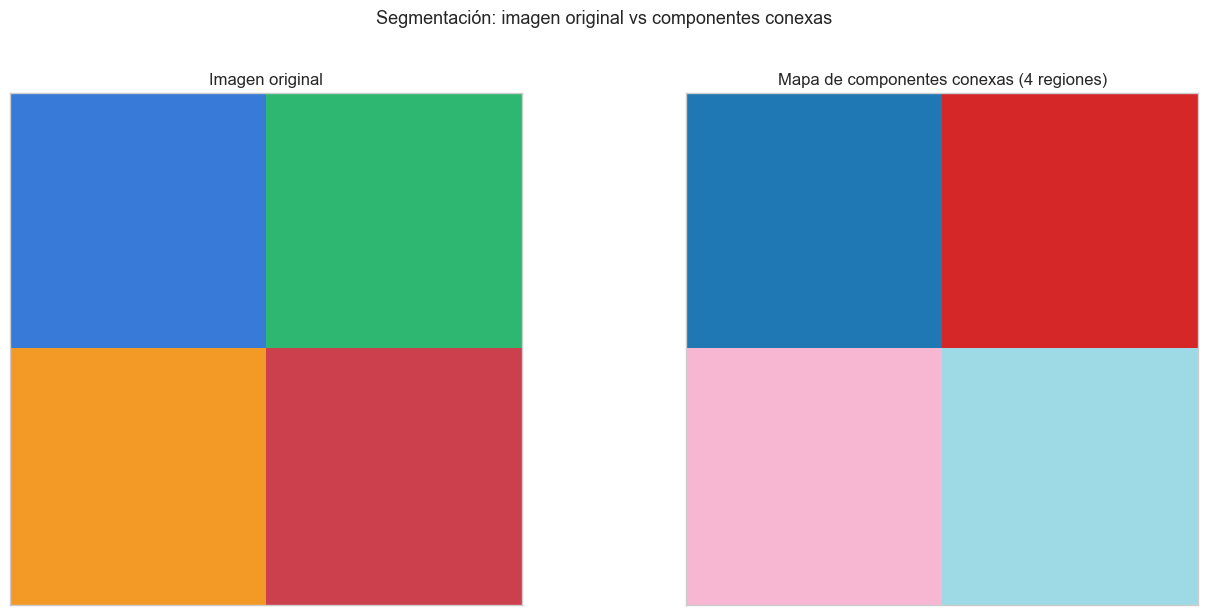

La imagen tiene 4 componentes conexas.
Aunque solo hay 4 colores, las regiones no siempre son conexas —
el ruido puede crear 'islas' separadas del mismo color.


In [12]:
# Visualizar las etiquetas de componentes
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Imagen original
axes[0].imshow(grilla_a_imagen(grid_colores), interpolation='nearest', aspect='equal')
axes[0].set_title('Imagen original', fontsize=12)
axes[0].set_xticks([]); axes[0].set_yticks([])

# Mapa de etiquetas
n_comp = len(componentes)
cmap_comp = plt.cm.get_cmap('tab20', n_comp)
axes[1].imshow(etiquetas, cmap=cmap_comp, vmin=0, vmax=n_comp-1,
               interpolation='nearest', aspect='equal')
axes[1].set_title(f'Mapa de componentes conexas ({n_comp} regiones)', fontsize=12)
axes[1].set_xticks([]); axes[1].set_yticks([])

plt.suptitle('Segmentación: imagen original vs componentes conexas', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"La imagen tiene {len(componentes)} componentes conexas.")
print("Aunque solo hay 4 colores, las regiones no siempre son conexas —")
print("el ruido puede crear 'islas' separadas del mismo color.")


---
## Sección 5: Recoloración y Segmentación Final

Una aplicación directa del flood fill es la **recoloración**: asignar un color único
a cada componente conexa, independientemente del color original.

Esto produce una **segmentación** de la imagen: cada región conectada se convierte
en un segmento distinto.

En visión computacional, esto se llama **connected components labeling** y es un
paso fundamental en:
- Análisis de documentos (separar caracteres)
- Detección de objetos en imágenes binarias
- Conteo de células en imágenes de microscopía

La complejidad es $O(H \times W)$ — lineal en el número de píxeles, lo que es
óptimo porque necesitamos leer cada píxel al menos una vez.


/var/folders/m8/ddjl62rx6015fvcr1g9p9nt80000gn/T/ipykernel_48491/2536482760.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('hsv', n_comp + 1)


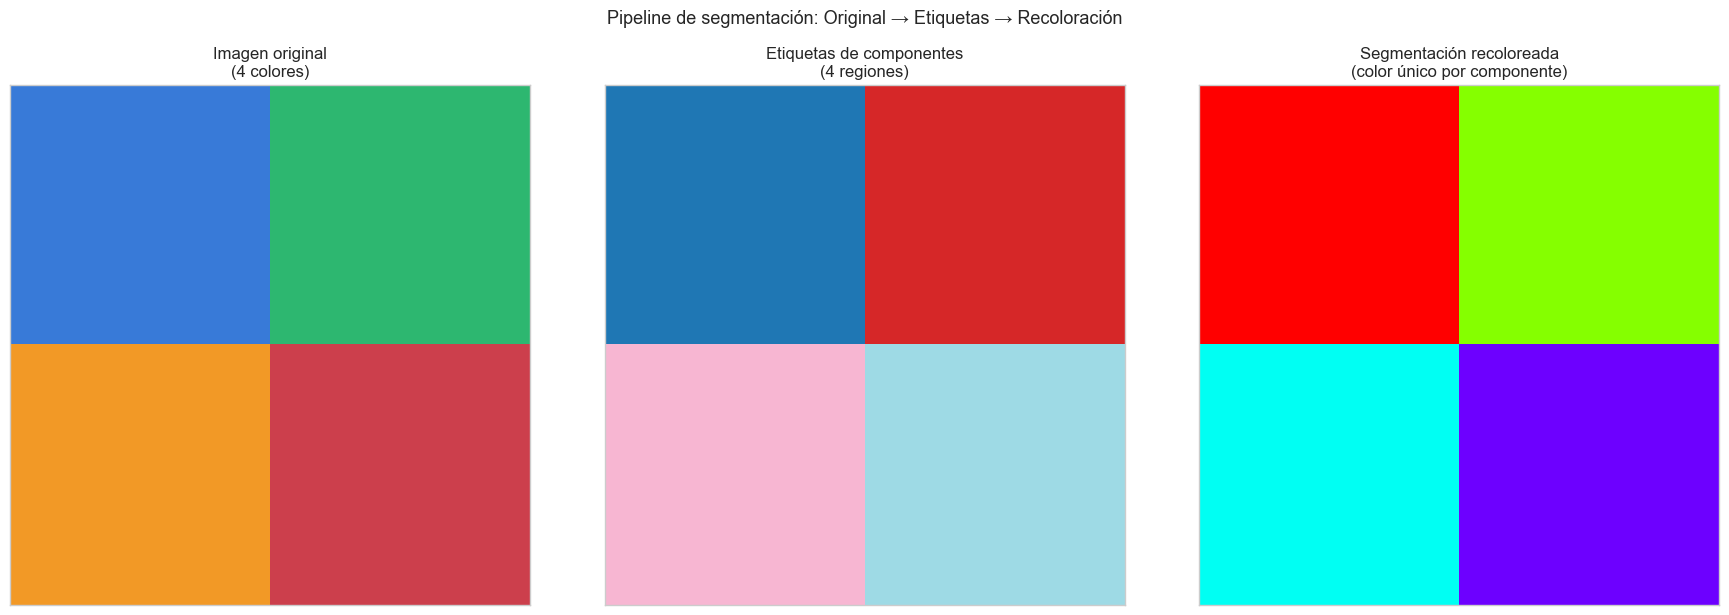

In [13]:
# Recolorear cada componente con un color único
def recolorear_componentes(etiquetas, componentes):
    """Asigna un color RGB único a cada componente conexa."""
    n_comp = len(componentes)
    filas, cols = etiquetas.shape
    img_seg = np.zeros((filas, cols, 3))

    # Generar una paleta de colores distinguibles
    cmap = plt.cm.get_cmap('hsv', n_comp + 1)
    paleta = np.array([cmap(i)[:3] for i in range(n_comp)])

    for r in range(filas):
        for c in range(cols):
            etiq = etiquetas[r, c]
            if etiq >= 0:
                img_seg[r, c] = paleta[etiq]

    return img_seg, paleta


img_segmentada, paleta_seg = recolorear_componentes(etiquetas, componentes)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original
axes[0].imshow(grilla_a_imagen(grid_colores), interpolation='nearest', aspect='equal')
axes[0].set_title('Imagen original\n(4 colores)', fontsize=12)
axes[0].set_xticks([]); axes[0].set_yticks([])

# Mapa de etiquetas
axes[1].imshow(etiquetas, cmap=plt.cm.tab20, vmin=0, vmax=len(componentes)-1,
               interpolation='nearest', aspect='equal')
axes[1].set_title(f'Etiquetas de componentes\n({len(componentes)} regiones)', fontsize=12)
axes[1].set_xticks([]); axes[1].set_yticks([])

# Segmentación recoloreada
axes[2].imshow(img_segmentada, interpolation='nearest', aspect='equal')
axes[2].set_title(f'Segmentación recoloreada\n(color único por componente)', fontsize=12)
axes[2].set_xticks([]); axes[2].set_yticks([])

plt.suptitle('Pipeline de segmentación: Original → Etiquetas → Recoloración',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


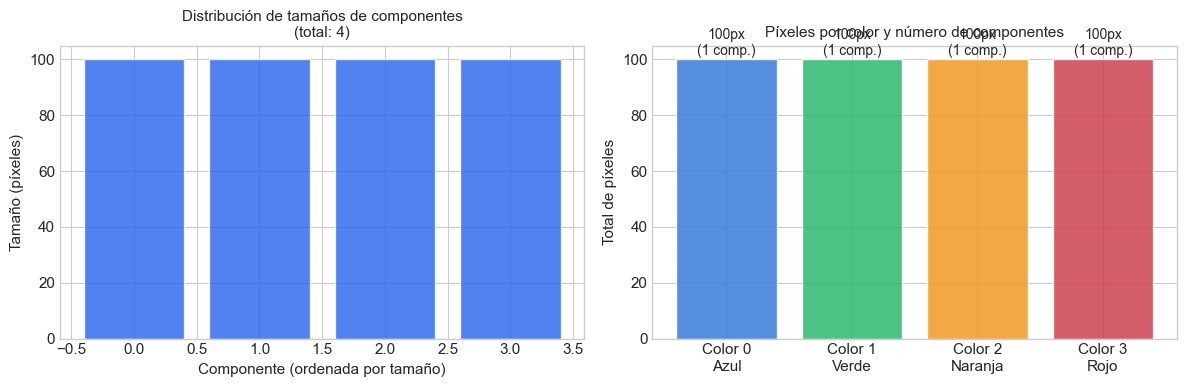

Resumen:
  Color 0 (Azul): 1 componentes, 100 px totales
  Color 1 (Verde): 1 componentes, 100 px totales
  Color 2 (Naranja): 1 componentes, 100 px totales
  Color 3 (Rojo): 1 componentes, 100 px totales


In [14]:
# Estadísticas de la segmentación
tamanios = sorted([len(px) for _, px, _ in componentes], reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(tamanios)), tamanios, color='#2563EB', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Componente (ordenada por tamaño)', fontsize=11)
axes[0].set_ylabel('Tamaño (píxeles)', fontsize=11)
axes[0].set_title(f'Distribución de tamaños de componentes\n(total: {len(componentes)})', fontsize=11)

# Distribución por color
por_color = {i: [] for i in range(4)}
for color, pixeles, _ in componentes:
    por_color[color].append(len(pixeles))

colores_mpl = [PALETA_REGIONES[i] for i in range(4)]
for i in range(4):
    tam_total = sum(por_color[i])
    n_comp_color = len(por_color[i])
    axes[1].bar(i, tam_total, color=PALETA_REGIONES[i], alpha=0.85, edgecolor='white')
    axes[1].text(i, tam_total + 0.5,
                 f"{tam_total}px\n({n_comp_color} comp.)",
                 ha='center', va='bottom', fontsize=10)

axes[1].set_xticks(range(4))
axes[1].set_xticklabels([f'Color {i}\n{NOMBRES_COLORES[i]}' for i in range(4)])
axes[1].set_ylabel('Total de píxeles', fontsize=11)
axes[1].set_title('Píxeles por color y número de componentes', fontsize=11)

plt.tight_layout()
plt.show()

print("Resumen:")
for i in range(4):
    print(f"  Color {i} ({NOMBRES_COLORES[i]}): {len(por_color[i])} componentes, "
          f"{sum(por_color[i])} px totales")


---
## 🔧 Ejercicios

### Ejercicio 1: Flood fill con tolerancia de color

En la mayoría de los programas de dibujo, el flood fill no requiere que los píxeles
sean exactamente el mismo color — acepta una **tolerancia** $\varepsilon$.

Modifica `ProblemaPixeles` para que acepte vecinos cuyo color sea similar a la semilla:

$$\text{vecino válido} \iff |\text{color}(v) - \text{color}(\text{semilla})| \le \varepsilon$$

Genera una grilla de escala de grises con gradiente suave y prueba flood fills
con $\varepsilon \in \{0.05, 0.15, 0.3\}$. ¿Cómo crece la región con la tolerancia?


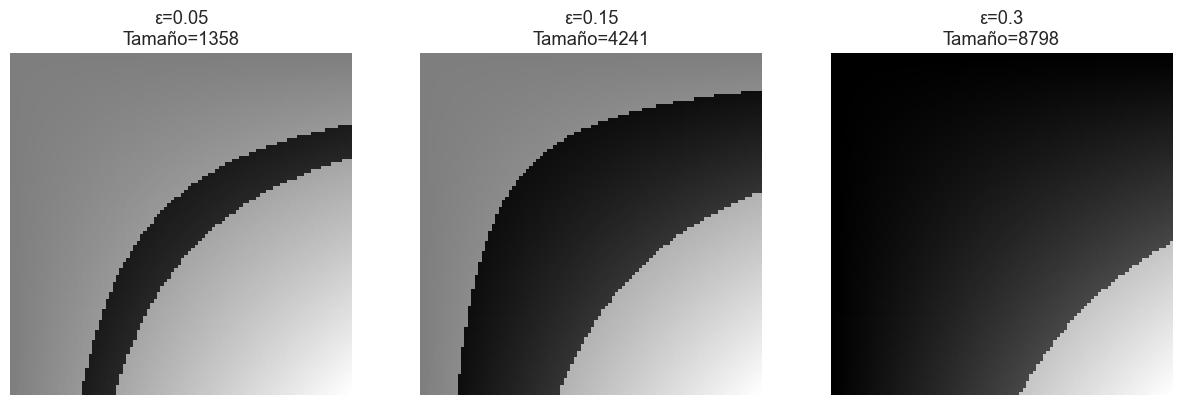

In [16]:
class ProblemaPixelesTolerante(Problema):
    def __init__(self, grid_continuo, semilla, tolerancia=0.1):
        """
        grid_continuo: array numpy de floats en [0, 1]
        tolerancia: máxima diferencia aceptada entre colores
        """
        self.grid = grid_continuo
        self.semilla = semilla
        self.tolerancia = tolerancia

        # guardar color de la semilla (clave del ejercicio)
        self.color_semilla = self.grid[semilla]

        self.filas = grid_continuo.shape[0]
        self.cols = grid_continuo.shape[1]

    def vecinos(self, pixel):
        f, c = pixel
        movimientos = [(-1,0),(1,0),(0,-1),(0,1)]
        vecinos_validos = []

        for df, dc in movimientos:
            nf, nc = f + df, c + dc

            # checar límites
            if 0 <= nf < self.filas and 0 <= nc < self.cols:

                # condición de tolerancia 🔥
                if abs(self.grid[nf, nc] - self.color_semilla) <= self.tolerancia:
                    vecinos_validos.append((nf, nc))

        return vecinos_validos      
    
# 1. Generar grilla suave
n = 100
x = np.linspace(0, 1, n)
grid = np.outer(x, x)  # gradiente suave

# 2. Flood fill tolerante (BFS)
def flood_fill_tolerante(grid, semilla, eps):
    filas, cols = grid.shape
    color_semilla = grid[semilla]

    visitados = set([semilla])
    cola = deque([semilla])

    while cola:
        f, c = cola.popleft()

        for df, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            nf, nc = f + df, c + dc

            if 0 <= nf < filas and 0 <= nc < cols:
                if (nf, nc) not in visitados:
                    if abs(grid[nf, nc] - color_semilla) <= eps:
                        visitados.add((nf, nc))
                        cola.append((nf, nc))

    return visitados

# 3. Ejecutar con diferentes eps
semilla = (50, 50)
epsilons = [0.05, 0.15, 0.3]

resultados = []

for eps in epsilons:
    region = flood_fill_tolerante(grid, semilla, eps)

    mask = np.zeros_like(grid)
    for (f, c) in region:
        mask[f, c] = 1

    resultados.append((eps, mask, len(region)))

# 4. Visualización
fig, axes = plt.subplots(1, 3, figsize=(15,5))

for i, (eps, mask, size) in enumerate(resultados):
    axes[i].imshow(grid, cmap='gray')
    axes[i].imshow(mask, alpha=0.5)  # overlay
    axes[i].set_title(f"ε={eps}\nTamaño={size}")
    axes[i].axis('off')

plt.show()      

### Ejercicio 2: Conteo de islas

El problema clásico de "conteo de islas" en LeetCode/programación competitiva:
dada una cuadrícula binaria donde `1` = tierra y `0` = agua, contar el número de islas
(componentes conexas de celdas con valor `1`).

Implementa `contar_islas(grid)` usando flood fill. Verifica que el resultado es 3.
Luego prueba con variantes 8-conectadas (incluyendo diagonales).


In [17]:
isla_grid = np.array([
    [1, 1, 0, 0, 0],
    [1, 1, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 1, 1],
    [0, 0, 0, 1, 1],
])

# Definir flood fill genérico
def flood_fill(grid, inicio, visitados, diagonales=False):
    filas, cols = grid.shape

    if diagonales:
        movimientos = [
            (-1, 0), (1, 0), (0, -1), (0, 1),
            (-1, -1), (-1, 1), (1, -1), (1, 1)
        ]
    else:
        movimientos = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    cola = deque([inicio])
    visitados.add(inicio)

    while cola:
        f, c = cola.popleft()

        for df, dc in movimientos:
            nf, nc = f + df, c + dc

            if 0 <= nf < filas and 0 <= nc < cols:
                if grid[nf, nc] == 1 and (nf, nc) not in visitados:
                    visitados.add((nf, nc))
                    cola.append((nf, nc))

# Contar islas
def contar_islas(grid, diagonales=False):
    filas, cols = grid.shape
    visitados = set()
    contador = 0

    for f in range(filas):
        for c in range(cols):
            if grid[f, c] == 1 and (f, c) not in visitados:
                contador += 1
                flood_fill(grid, (f, c), visitados, diagonales=diagonales)

    return contador

# Probar versión 4-conectada
resultado_4 = contar_islas(isla_grid, diagonales=False)
print("Número de islas (4-conectado):", resultado_4)

# Probar versión 8-conectada
resultado_8 = contar_islas(isla_grid, diagonales=True)
print("Número de islas (8-conectado):", resultado_8)

Número de islas (4-conectado): 3
Número de islas (8-conectado): 1


### Ejercicio 3: Segmentación por umbral

Una imagen en escala de grises se puede segmentar en "fondo" (píxeles claros) y
"objeto" (píxeles oscuros) usando un umbral $T$.

Genera una imagen sintética con un objeto circular oscuro sobre fondo claro:

1. Umbraliza la imagen: `binaria = (img < T).astype(int)` con $T = 0.5$
2. Aplica flood fill para encontrar todas las componentes conexas de valor `1`
3. Identifica la componente más grande (el círculo)
4. Visualiza la imagen original, la imagen umbralizada y el objeto detectado

Número de componentes detectadas: 1
Tamaño de la componente más grande: 709


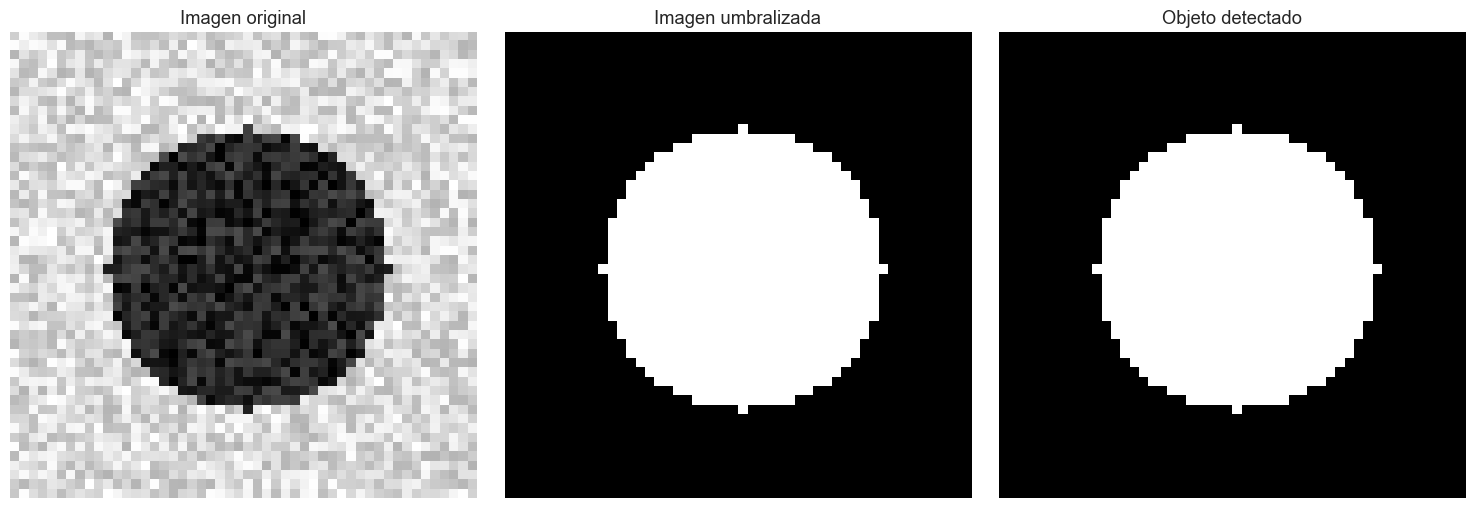

In [18]:
def imagen_circulo(n=50, r_circulo=15, seed=42):
    """Imagen n×n con un círculo oscuro en el centro + ruido gaussiano."""
    np.random.seed(seed)
    img = np.random.uniform(0.7, 1.0, (n, n))  # fondo claro
    centro = (n//2, n//2)
    for i in range(n):
        for j in range(n):
            if (i - centro[0])**2 + (j - centro[1])**2 <= r_circulo**2:
                img[i, j] = np.random.uniform(0.0, 0.3)  # objeto oscuro
    return img

# Flood fill para una componente
def flood_fill_componente(grid, inicio, visitados):
    filas, cols = grid.shape
    movimientos = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    cola = deque([inicio])
    visitados.add(inicio)
    componente = [inicio]

    while cola:
        f, c = cola.popleft()

        for df, dc in movimientos:
            nf, nc = f + df, c + dc

            if 0 <= nf < filas and 0 <= nc < cols:
                if grid[nf, nc] == 1 and (nf, nc) not in visitados:
                    visitados.add((nf, nc))
                    cola.append((nf, nc))
                    componente.append((nf, nc))

    return componente

# Encontrar componentes conexas
def encontrar_componentes(grid):
    filas, cols = grid.shape
    visitados = set()
    componentes = []

    for i in range(filas):
        for j in range(cols):
            if grid[i, j] == 1 and (i, j) not in visitados:
                comp = flood_fill_componente(grid, (i, j), visitados)
                componentes.append(comp)

    return componentes

# Generar imagen y umbralizar
img = imagen_circulo(n=50, r_circulo=15, seed=42)

T = 0.5
binaria = (img < T).astype(int)

# Encontrar componenetes y la más grande
componentes = encontrar_componentes(binaria)
componente_mas_grande = max(componentes, key=len)

objeto_detectado = np.zeros_like(binaria)
for f, c in componente_mas_grande:
    objeto_detectado[f, c] = 1

print("Número de componentes detectadas:", len(componentes))
print("Tamaño de la componente más grande:", len(componente_mas_grande))

# Visualizar resultados
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title("Imagen original")
axes[0].axis("off")

axes[1].imshow(binaria, cmap='gray')
axes[1].set_title("Imagen umbralizada")
axes[1].axis("off")

axes[2].imshow(objeto_detectado, cmap='gray')
axes[2].set_title("Objeto detectado")
axes[2].axis("off")

plt.tight_layout()
plt.show()